<a href="https://colab.research.google.com/github/PromitMukherjee/Machine_learning_Algorithm/blob/main/Unsupervised_Learning/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Unsupervised Learning: Logistic Regression
import numpy as np


class LogisticRegression:

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

        self.coef_ = None
        self.intercept_ = None
        self.loss_history_ = []

    # --------------------------------------------------
    # 1. Sigmoid function
    # --------------------------------------------------
    def _sigmoid(self, z):

        # Prevent numerical overflow
        z = np.clip(z, -500, 500)

        return 1 / (1 + np.exp(-z))

    # --------------------------------------------------
    # 2. Binary Cross-Entropy Loss
    # --------------------------------------------------
    def _compute_loss(self, y, y_prob):

        # Prevent log(0)
        epsilon = 1e-15

        y_prob = np.clip(
            y_prob,
            epsilon,
            1 - epsilon
        )

        loss = -np.mean(
            y * np.log(y_prob)
            +
            (1 - y) * np.log(1 - y_prob)
        )

        return loss

    # --------------------------------------------------
    # 3. Training
    # --------------------------------------------------
    def fit(self, X, y):

        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_features = X.shape

        # Initialize parameters
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0

        self.loss_history_ = []

        # Gradient Descent
        for iteration in range(self.n_iterations):

            # ------------------------------------------
            # Step 1: Linear combination
            # z = Xw + b
            # ------------------------------------------
            z = X @ self.coef_ + self.intercept_

            # ------------------------------------------
            # Step 2: Convert score to probability
            # p = sigmoid(z)
            # ------------------------------------------
            y_prob = self._sigmoid(z)

            # ------------------------------------------
            # Step 3: Calculate loss
            # ------------------------------------------
            loss = self._compute_loss(y, y_prob)

            self.loss_history_.append(loss)

            # ------------------------------------------
            # Step 4: Calculate gradients
            # ------------------------------------------

            error = y_prob - y

            # Gradient with respect to weights
            dw = (X.T @ error) / n_samples

            # Gradient with respect to bias
            db = np.mean(error)

            # ------------------------------------------
            # Step 5: Update parameters
            # ------------------------------------------

            self.coef_ -= self.learning_rate * dw

            self.intercept_ -= self.learning_rate * db

        return self

    # --------------------------------------------------
    # 4. Predict probabilities
    # --------------------------------------------------
    def predict_proba(self, X):

        X = np.asarray(X, dtype=float)

        z = X @ self.coef_ + self.intercept_

        return self._sigmoid(z)

    # --------------------------------------------------
    # 5. Predict class
    # --------------------------------------------------
    def predict(self, X):

        probabilities = self.predict_proba(X)

        return (probabilities >= 0.5).astype(int)

    # --------------------------------------------------
    # 6. Accuracy score
    # --------------------------------------------------
    def score(self, X, y):

        y = np.asarray(y)

        predictions = self.predict(X)

        return np.mean(predictions == y)

Weights: [2.26372411]
Bias: -7.703904480281582

Probabilities:
[0.00431996 0.04006139 0.28644108 0.79429175 0.97378136 0.99720867]

Predictions:
[0 0 0 1 1 1]

Accuracy:
1.0

Decision Boundary: 3.403199379109709


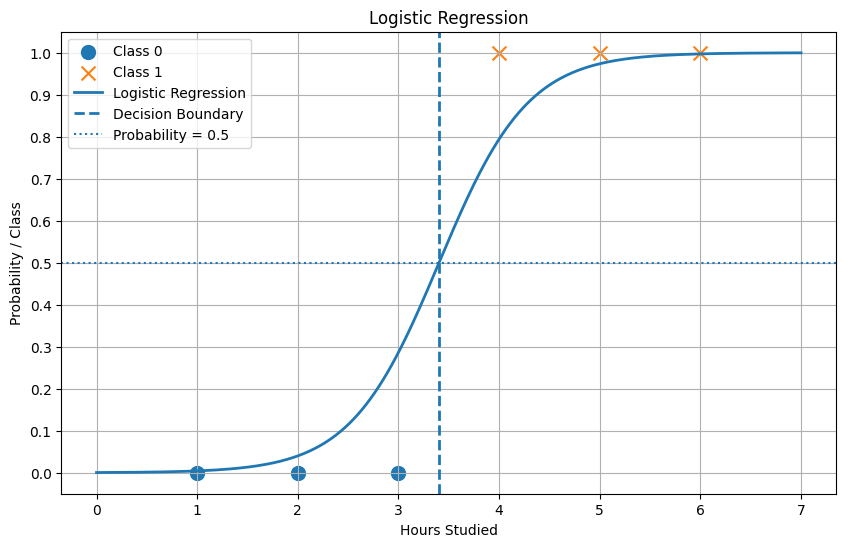

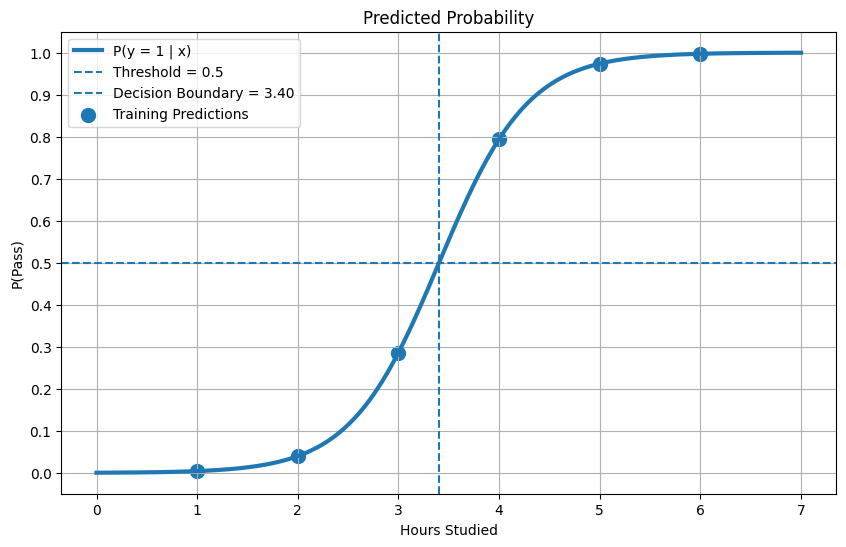

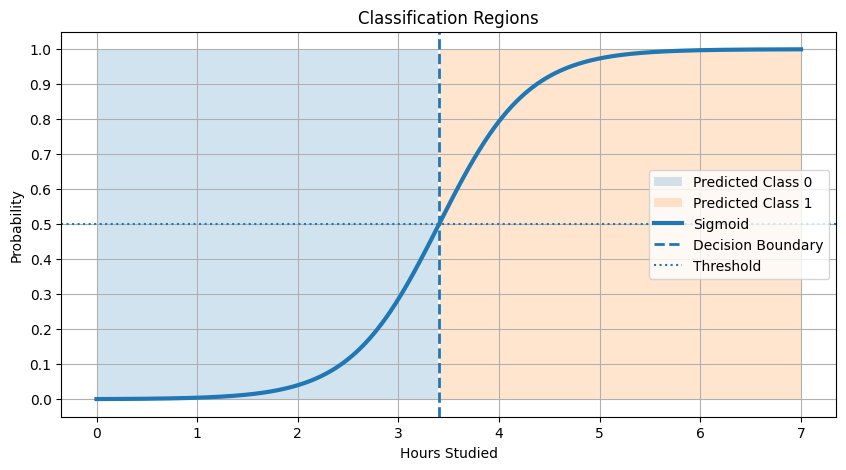

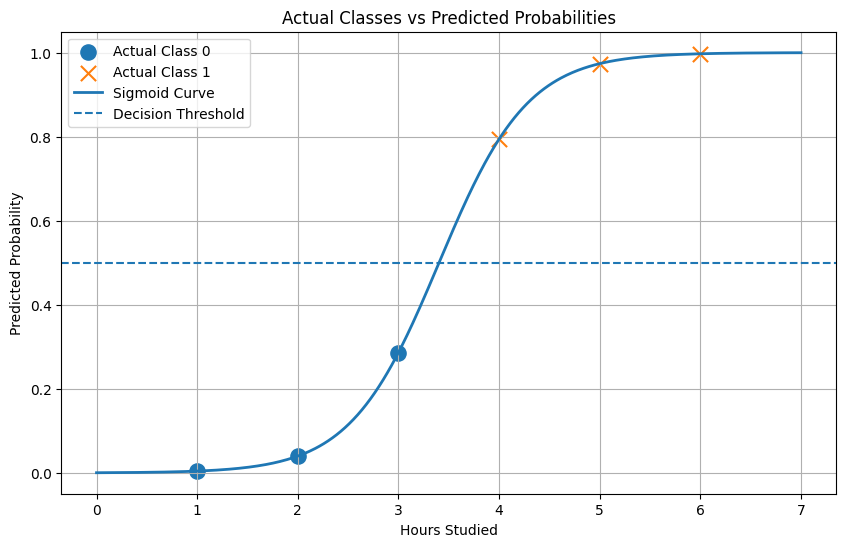

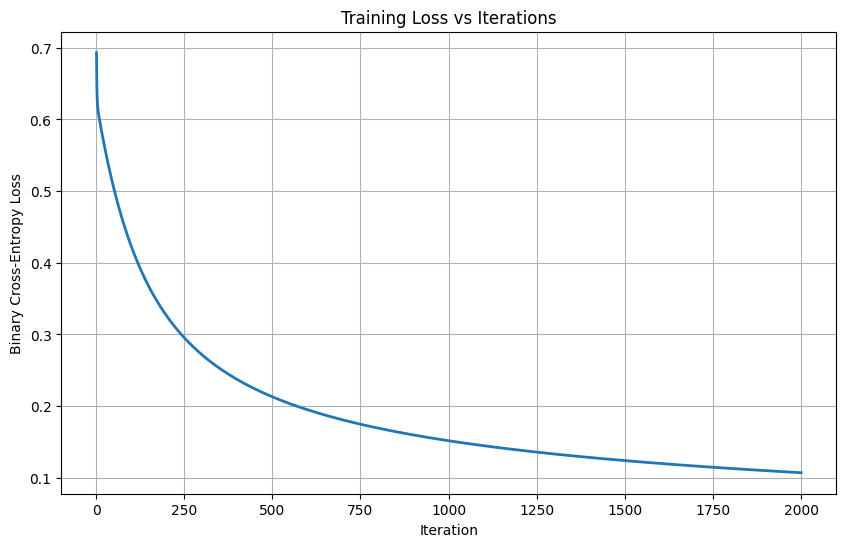

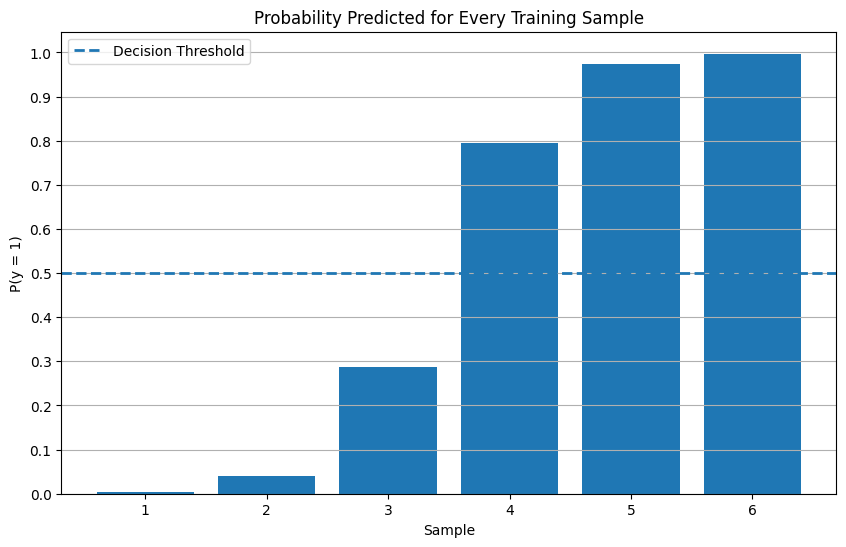

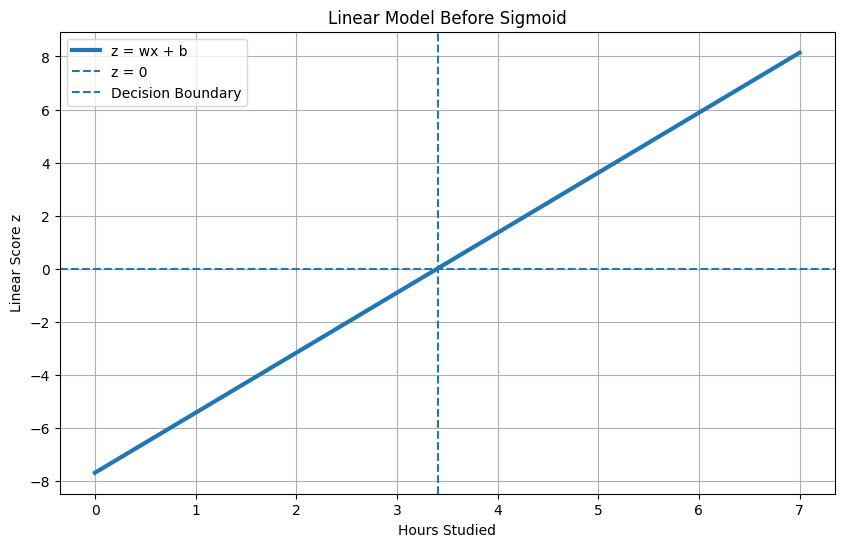

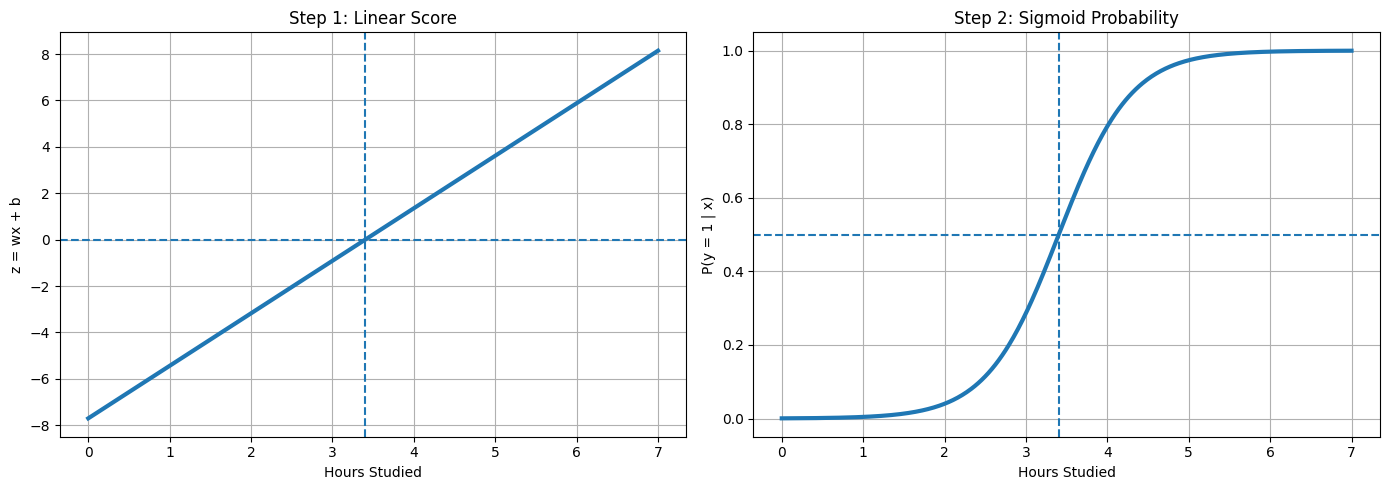

In [2]:
import matplotlib.pyplot as plt


# ============================================================
# Your dataset
# ============================================================

X = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6]
])

y = np.array([
    0,
    0,
    0,
    1,
    1,
    1
])


# ============================================================
# Train model
# ============================================================

model = LogisticRegression(
    learning_rate=0.1,
    n_iterations=2000
)

model.fit(X, y)


# ============================================================
# Basic results
# ============================================================

print("Weights:", model.coef_)
print("Bias:", model.intercept_)

print("\nProbabilities:")
print(model.predict_proba(X))

print("\nPredictions:")
print(model.predict(X))

print("\nAccuracy:")
print(model.score(X, y))


# ============================================================
# Create smooth X values for plotting
# ============================================================

x_grid = np.linspace(
    X.min() - 1,
    X.max() + 1,
    500
).reshape(-1, 1)


# ============================================================
# Predicted probabilities over the smooth grid
# ============================================================

probabilities = model.predict_proba(x_grid)


# ============================================================
# Decision boundary
#
# sigmoid(z) = 0.5
#
# sigmoid(z) = 0.5 happens when:
#
# z = wx + b = 0
#
# Therefore:
#
# x = -b / w
# ============================================================

decision_boundary = (
    -model.intercept_
    / model.coef_[0]
)


print("\nDecision Boundary:", decision_boundary)


# ============================================================
# FIGURE 1
# Training data + Logistic Regression curve
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X[y == 0],
    y[y == 0],
    marker="o",
    s=100,
    label="Class 0"
)

plt.scatter(
    X[y == 1],
    y[y == 1],
    marker="x",
    s=100,
    label="Class 1"
)

plt.plot(
    x_grid,
    probabilities,
    linewidth=2,
    label="Logistic Regression"
)

plt.axvline(
    decision_boundary,
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)

plt.axhline(
    0.5,
    linestyle=":",
    label="Probability = 0.5"
)

plt.xlabel("Hours Studied")
plt.ylabel("Probability / Class")
plt.title("Logistic Regression")

plt.xticks(np.arange(
    int(X.min()) - 1,
    int(X.max()) + 2,
    1
))

plt.yticks(
    np.arange(0, 1.1, 0.1)
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# FIGURE 2
# Probability curve only
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    x_grid,
    probabilities,
    linewidth=3,
    label="P(y = 1 | x)"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Threshold = 0.5"
)

plt.axvline(
    decision_boundary,
    linestyle="--",
    label=f"Decision Boundary = {decision_boundary:.2f}"
)

plt.scatter(
    X,
    model.predict_proba(X),
    s=100,
    label="Training Predictions"
)

plt.xlabel("Hours Studied")
plt.ylabel("P(Pass)")
plt.title("Predicted Probability")

plt.xticks(np.arange(
    int(X.min()) - 1,
    int(X.max()) + 2,
    1
))

plt.yticks(
    np.arange(0, 1.1, 0.1)
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# FIGURE 3
# Classification regions
# ============================================================

plt.figure(figsize=(10, 5))

plt.fill_between(
    x_grid.flatten(),
    0,
    1,
    where=(probabilities.flatten() < 0.5),
    alpha=0.2,
    label="Predicted Class 0"
)

plt.fill_between(
    x_grid.flatten(),
    0,
    1,
    where=(probabilities.flatten() >= 0.5),
    alpha=0.2,
    label="Predicted Class 1"
)

plt.plot(
    x_grid,
    probabilities,
    linewidth=3,
    label="Sigmoid"
)

plt.axvline(
    decision_boundary,
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)

plt.axhline(
    0.5,
    linestyle=":",
    label="Threshold"
)

plt.xlabel("Hours Studied")
plt.ylabel("Probability")
plt.title("Classification Regions")

plt.xticks(np.arange(
    int(X.min()) - 1,
    int(X.max()) + 2,
    1
))

plt.yticks(
    np.arange(0, 1.1, 0.1)
)

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# FIGURE 4
# Actual labels vs predicted probabilities
# ============================================================

plt.figure(figsize=(10, 6))

predicted_probabilities = model.predict_proba(X)

plt.scatter(
    X[y == 0],
    predicted_probabilities[y == 0],
    s=120,
    marker="o",
    label="Actual Class 0"
)

plt.scatter(
    X[y == 1],
    predicted_probabilities[y == 1],
    s=120,
    marker="x",
    label="Actual Class 1"
)

plt.plot(
    x_grid,
    probabilities,
    linewidth=2,
    label="Sigmoid Curve"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Threshold"
)

plt.xlabel("Hours Studied")
plt.ylabel("Predicted Probability")
plt.title("Actual Classes vs Predicted Probabilities")

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# FIGURE 5
# Loss vs Iterations
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(model.loss_history_) + 1),
    model.loss_history_,
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss vs Iterations")

plt.grid(True)

plt.show()


# ============================================================
# FIGURE 6
# Prediction probability for every sample
# ============================================================

plt.figure(figsize=(10, 6))

sample_numbers = np.arange(1, len(X) + 1)

plt.bar(
    sample_numbers,
    predicted_probabilities
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="Decision Threshold"
)

plt.xlabel("Sample")
plt.ylabel("P(y = 1)")
plt.title("Probability Predicted for Every Training Sample")

plt.xticks(sample_numbers)

plt.yticks(
    np.arange(0, 1.1, 0.1)
)

plt.grid(
    axis="y"
)

plt.legend()

plt.show()


# ============================================================
# FIGURE 7
# Linear score z = wx + b
# ============================================================

linear_scores = (
    x_grid * model.coef_[0]
    + model.intercept_
)


plt.figure(figsize=(10, 6))

plt.plot(
    x_grid,
    linear_scores,
    linewidth=3,
    label="z = wx + b"
)

plt.axhline(
    0,
    linestyle="--",
    label="z = 0"
)

plt.axvline(
    decision_boundary,
    linestyle="--",
    label="Decision Boundary"
)

plt.xlabel("Hours Studied")
plt.ylabel("Linear Score z")
plt.title("Linear Model Before Sigmoid")

plt.grid(True)
plt.legend()

plt.show()


# ============================================================
# FIGURE 8
# Side-by-side conceptual visualization
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ------------------------------------------------------------
# Left: Linear score
# ------------------------------------------------------------

axes[0].plot(
    x_grid,
    linear_scores,
    linewidth=3
)

axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].axvline(
    decision_boundary,
    linestyle="--"
)

axes[0].set_xlabel("Hours Studied")
axes[0].set_ylabel("z = wx + b")
axes[0].set_title("Step 1: Linear Score")

axes[0].grid(True)


# ------------------------------------------------------------
# Right: Sigmoid probability
# ------------------------------------------------------------

axes[1].plot(
    x_grid,
    probabilities,
    linewidth=3
)

axes[1].axhline(
    0.5,
    linestyle="--"
)

axes[1].axvline(
    decision_boundary,
    linestyle="--"
)

axes[1].set_xlabel("Hours Studied")
axes[1].set_ylabel("P(y = 1 | x)")
axes[1].set_title("Step 2: Sigmoid Probability")

axes[1].grid(True)


plt.tight_layout()
plt.show()